In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

Data Cleaning

In [ ]:
df = pd.read_csv('/content/zomato.csv', encoding='latin1')
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [ ]:
df.shape

(51717, 17)

In [ ]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=51717, step=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

Deleting redundant columns

In [ ]:
unnamed_cols = [col for col in df.columns if col.startswith('Unnamed:')]
cols_to_drop = ['url','address','phone','menu_item','dish_liked','reviews_list','listed_in(city)'] + unnamed_cols
df.drop(cols_to_drop, axis=1, inplace=True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51717 non-null  object
 1   online_order                 51717 non-null  object
 2   book_table                   51717 non-null  object
 3   rate                         43942 non-null  object
 4   votes                        51717 non-null  int64 
 5   location                     51696 non-null  object
 6   rest_type                    51490 non-null  object
 7   cuisines                     51672 non-null  object
 8   approx_cost(for two people)  51371 non-null  object
 9   listed_in(type)              51717 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.9+ MB


Checking the null values by columns

In [ ]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
cuisines,45
approx_cost(for two people),346
listed_in(type),0


In [ ]:
df.isnull().sum().sum()

np.int64(8414)

Renaming the columns

In [ ]:
df.rename(columns={'name':'restaurants','book_table':'booking','listed_in(city)':'city','rate':'rating','approx_cost(for two people)':'cost','listed_in(type)':'types'},inplace=True)
df.head()

,restaurants,online_order,booking,rating,votes,location,rest_type,cuisines,cost,types
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


Dropping duplicates.

In [ ]:
len(df)

51717

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().values.any()

np.False_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43533 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   restaurants   43533 non-null  object
 1   online_order  43533 non-null  object
 2   booking       43533 non-null  object
 3   rating        43533 non-null  object
 4   votes         43533 non-null  int64 
 5   location      43533 non-null  object
 6   rest_type     43533 non-null  object
 7   cuisines      43533 non-null  object
 8   cost          43533 non-null  object
 9   types         43533 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.7+ MB


In [ ]:
df[df.duplicated()].count().sum()

np.int64(125750)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(30958, 10)

In [ ]:
df[df.duplicated()].count().sum()

np.int64(0)

Cleaning individual columns

column :ratings

In [ ]:
df['rating'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [ ]:
df['rating'].replace("NEW|-",'0',regex=True).replace('/5','',regex=True).unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', '0', '2.9', '3.5', '2.6',
       '3.8 ', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3',
       '3.4 ', '3.6 ', '4.8', '3.9 ', '4.2 ', '4.0 ', '4.1 ', '3.7 ',
       '3.1 ', '2.9 ', '3.3 ', '2.8 ', '3.5 ', '2.7 ', '2.5 ', '3.2 ',
       '2.6 ', '4.5 ', '4.3 ', '4.4 ', '4.9', '2.1', '2.0', '1.8', '4.6 ',
       '4.9 ', '3.0 ', '4.8 ', '2.3 ', '4.7 ', '2.4 ', '2.1 ', '2.2 ',
       '2.0 ', '1.8 '], dtype=object)

In [ ]:
df['rating'] = df['rating'].astype(str).replace('/5', '', regex=True)
df['rating'] = df['rating'].astype(str).replace("NEW|-", '0', regex=True)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].fillna(0)
df['rating'].head()

,rating
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [ ]:
#Counting the NaN valuesn in rating column
df['rating'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30958 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   restaurants   30958 non-null  object 
 1   online_order  30958 non-null  object 
 2   booking       30958 non-null  object 
 3   rating        30958 non-null  float64
 4   votes         30958 non-null  int64  
 5   location      30958 non-null  object 
 6   rest_type     30958 non-null  object 
 7   cuisines      30958 non-null  object 
 8   cost          30958 non-null  object 
 9   types         30958 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 2.6+ MB


column :location

In [ ]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Bannerghatta Road', 'BTM', 'Kanakapura Road', 'Bommanahalli',
       'CV Raman Nagar', 'Electronic City', 'Wilson Garden',
       'Shanti Nagar', 'Koramangala 5th Block', 'Richmond Road', 'HSR',
       'Marathahalli', 'Koramangala 7th Block', 'Bellandur',
       'Sarjapur Road', 'Whitefield', 'East Bangalore',
       'Old Airport Road', 'Indiranagar', 'Koramangala 1st Block',
       'Frazer Town', 'MG Road', 'Brigade Road', 'Lavelle Road',
       'Church Street', 'Ulsoor', 'Residency Road', 'Shivajinagar',
       'Infantry Road', 'St. Marks Road', 'Cunningham Road',
       'Race Course Road', 'Commercial Street', 'Vasanth Nagar', 'Domlur',
       'Koramangala 8th Block', 'Ejipura', 'Jeevan Bhima Nagar',
       'Old Madras Road', 'Seshadripuram', 'Kammanahalli',
       'Koramanga

In [ ]:
df['location'].isnull().sum()

np.int64(0)

In [ ]:
a =df['location'].value_counts(ascending=False)
a

,count
location,
BTM,2228
Indiranagar,1653
Whitefield,1630
Koramangala 5th Block,1577
HSR,1558
...,...
Kengeri,5
Yelahanka,4
Rajarajeshwari Nagar,2


column : cost

In [ ]:
df['cost'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '1,700', '1,400', '1,350', '2,200', '2,000',
       '1,800', '1,900', '180', '330', '2,500', '2,100', '3,000', '2,800',
       '3,400', '50', '40', '1,250', '3,500', '4,000', '2,400', '2,600',
       '1,450', '70', '3,200', '560', '240', '360', '6,000', '1,050',
       '2,300', '4,100', '120', '5,000', '3,700', '1,650', '2,700',
       '4,500'], dtype=object)

In [ ]:
df['cost'] = df['cost'].astype(str).replace(",", '', regex=True)
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
df['cost'] = df['cost'].fillna(0).astype(int)

In [ ]:
df['cost'].unique()

array([ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,
        750,  150,  850,  100, 1200,  350,  250,  950, 1000, 1500, 1300,
        199,   80, 1100,  160, 1600,  230,  130, 1700, 1400, 1350, 2200,
       2000, 1800, 1900,  180,  330, 2500, 2100, 3000, 2800, 3400,   50,
         40, 1250, 3500, 4000, 2400, 2600, 1450,   70, 3200,  560,  240,
        360, 6000, 1050, 2300, 4100,  120, 5000, 3700, 1650, 2700, 4500])

In [ ]:
df['cost'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30958 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   restaurants   30958 non-null  object 
 1   online_order  30958 non-null  object 
 2   booking       30958 non-null  object 
 3   rating        30958 non-null  float64
 4   votes         30958 non-null  int64  
 5   location      30958 non-null  object 
 6   rest_type     30958 non-null  object 
 7   cuisines      30958 non-null  object 
 8   cost          30958 non-null  int64  
 9   types         30958 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.6+ MB


columns : booking

In [ ]:
df['booking'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['booking'].isnull().sum()

np.int64(0)

columns : online order

In [ ]:
df['online_order'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['online_order'].isnull().sum()

np.int64(0)

column : rest type

In [ ]:
df['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Dessert Parlor, Sweet Shop', 'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites', 'Kiosk', 'Food Truck',
       'Quick Bites, Dessert Parlor', 'Beverage Shop, Quick Bites',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Microbrewery, Casual Dining', 'Lounge',
       'Bar, Casual Dining', 'Food Court', 'Cafe, Bakery', 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Quick Bites, Beverage Shop',
       'Pub, Bar', 'Casual Dining, Pub', 'Lounge, Bar',
       'Dessert Parlor, Quick Bites', 'Food Court, 

In [ ]:
df['rest_type'].isnull().any()

np.False_

In [ ]:
a =df['rest_type'].value_counts(ascending=False)
a

,count
rest_type,
Quick Bites,10143
Casual Dining,7311
Cafe,2495
Dessert Parlor,1357
Delivery,1117
...,...
"Bakery, Food Court",2
"Bakery, Beverage Shop",2
"Food Court, Beverage Shop",2


column : listed in type

In [ ]:
df['types'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [ ]:
c=df['types'].value_counts()
c

,count
types,
Delivery,14159
Dine-out,11354
Desserts,2117
Cafes,1184
Drinks & nightlife,894
Buffet,665
Pubs and bars,585


In [ ]:
df['types'].isnull().sum()

np.int64(0)

columns :cuisines

In [ ]:
b =df['cuisines'].value_counts()
b

,count
cuisines,
North Indian,1602
"North Indian, Chinese",1401
South Indian,902
"Bakery, Desserts",471
Biryani,429
...,...
"South Indian, North Indian, Chinese, Desserts, Fast Food, Ice Cream",1
"Mediterranean, Italian",1
"Biryani, Kebab, Chinese",1


In [ ]:
df['cuisines'].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ..., 'Tibetan, Nepalese',
       'North Indian, Street Food, Biryani',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

columns : restaurants

In [ ]:
df.groupby('restaurants').count().head()

,online_order,booking,rating,votes,location,rest_type,cuisines,cost,types
restaurants,,,,,,,,,
#FeelTheROLL,2,2,2,2,2,2,2,2,2
#L-81 Cafe,4,4,4,4,4,4,4,4,4
#refuel,3,3,3,3,3,3,3,3,3
1000 B.C,2,2,2,2,2,2,2,2,2
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,2,2,2,2,2,2,2,2,2


In [ ]:
df.groupby('restaurants').count().head()

,online_order,booking,rating,votes,location,rest_type,cuisines,cost,types
restaurants,,,,,,,,,
#FeelTheROLL,2,2,2,2,2,2,2,2,2
#L-81 Cafe,4,4,4,4,4,4,4,4,4
#refuel,3,3,3,3,3,3,3,3,3
1000 B.C,2,2,2,2,2,2,2,2,2
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,2,2,2,2,2,2,2,2,2


In [ ]:
df['restaurants']=df['restaurants'].str.replace('[Ãx][^A-Za-z]+','',regex=True)

In [ ]:
df.groupby('restaurants').count().head()

,online_order,booking,rating,votes,location,rest_type,cuisines,cost,types
restaurants,,,,,,,,,
#FeelTheROLL,2,2,2,2,2,2,2,2,2
#L-81 Cafe,4,4,4,4,4,4,4,4,4
#refuel,3,3,3,3,3,3,3,3,3
1000 B.C,2,2,2,2,2,2,2,2,2
100C,2,2,2,2,2,2,2,2,2


Remove the NaN values from the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30958 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   restaurants   30958 non-null  object 
 1   online_order  30958 non-null  object 
 2   booking       30958 non-null  object 
 3   rating        30958 non-null  float64
 4   votes         30958 non-null  int64  
 5   location      30958 non-null  object 
 6   rest_type     30958 non-null  object 
 7   cuisines      30958 non-null  object 
 8   cost          30958 non-null  int64  
 9   types         30958 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.6+ MB


In [ ]:
df.isnull().sum()

,0
restaurants,0
online_order,0
booking,0
rating,0
votes,0
location,0
rest_type,0
cuisines,0
cost,0
types,0


In [ ]:
df.to_csv('./clean_zomato.csv')
df

,restaurants,online_order,booking,rating,votes,location,rest_type,cuisines,cost,types
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...
51709,The Farm House Bar n Grill,No,No,3.7,34,Whitefield,"Casual Dining, Bar","North Indian, Continental",800,Pubs and bars
51711,Bhagini,No,No,2.5,81,Whitefield,"Casual Dining, Bar","Andhra, South Indian, Chinese, North Indian",800,Pubs and bars
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500,Pubs and bars
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500,Pubs and bars


Data visualization:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

Restaurant type

In [ ]:
#Restaurant type
type1=df['rest_type'].value_counts().head(5)
type1.to_frame()

,count
rest_type,
Quick Bites,10143
Casual Dining,7311
Cafe,2495
Dessert Parlor,1357
Delivery,1117


In [ ]:
fig=px.bar(x=type1.index,
           y=type1,
           color=type1.index # Each bar is colored differently
           ,title='Restaurant type',labels={'x':'Restaurant','y':'Count of Restaurant'} # changes x and y label
          )
fig.show()

Restaurants delivering Online or not

In [ ]:
delivery_or_not = df["online_order"].value_counts()
delivery_or_not

,count
online_order,
Yes,19818
No,11140


In [ ]:
fig=px.pie(delivery_or_not,
           title='Delivery or not',
           values=delivery_or_not, # values inside pie plot
           names=delivery_or_not.index # legend or names displayes with color
          )
fig.show()

In [ ]:
fig = px.violin(df,x='online_order', y="rating",
                color='online_order',
                box=True, # draw box plot inside the violin
                points='outliers', # can be 'outliers', or False
               )
fig.show()

Table booking Rate vs Rate

In [ ]:
fig= px.box(df,x='booking',
               y='rating',
            color='booking'
               )
fig.show()

Best Location

In [ ]:
#Best location(votes)
loc_vote=df.groupby('location')['votes'].sum()
loc_vote=loc_vote.nlargest(5).sort_values(ascending=True)
loc_vote

,votes
location,
JP Nagar,479180
Church Street,555228
Koramangala 4th Block,591240
Indiranagar,1129994
Koramangala 5th Block,1984132


In [ ]:
fig=px.bar(y=loc_vote.index,
           x=loc_vote,
           color=loc_vote.index # Each bar is colored differently
           ,title='Best location by votes',labels={'x':'Location','y':'Votes'} # changes x and y label
          )
fig.show()

Best location(ratings) & Location vs Rating

In [ ]:
#Best location(ratings) & Location vs Rating
loc_rate=df.groupby('location')['rating'].sum()
loc_rate=loc_rate.nlargest(5).sort_values()
loc_rate.head()

,rating
location,
HSR,5490.4
Whitefield,5576.6
Indiranagar,6110.9
Koramangala 5th Block,6364.2
BTM,7610.6


In [ ]:
fig=px.bar(y=loc_rate.index,
           x=loc_rate,
           color=loc_vote.index # Each bar is colored differently
           ,title='Best location by rating',labels={'x':'Location','y':'Rating'} # changes x and y label
          )
fig.show()

Cost of Restaurant

In [ ]:
fig=px.histogram(df['cost'],nbins=100)
fig.show()

Most famous restaurant chains in Bengaluru(votes)

In [ ]:
#Most famous restaurant chains in Bengaluru(votes)
vote=df.groupby('restaurants')[['votes','rating']].agg('mean').sort_values(by=['rating','votes'],ascending=False).head(10)
vote

,votes,rating
restaurants,,
Byg Brewski Brewing Company,16588.500000,4.900000
Asia Kitchen By Mainland China,2224.894737,4.900000
SantSpa Cuisine,246.000000,4.900000
Punjab Grill,1380.000000,4.871429
Belgian Waffle Factory,957.190476,4.852381
Flechazo,4992.666667,4.800000
The Pizza Bakery,1753.833333,4.800000
O.G. Variar & Sons,1158.500000,4.800000
AB's - Absolute Barbecues,4445.222222,4.783333


In [ ]:
fig=px.bar(y=vote['votes'],
           x=vote.index,
           color=vote.index # Each bar is colored differently
           ,title='Best location by rating',labels={'x':'Location','y':'Rating'} # changes x and y label
          )
fig.show()

Relation between Type and Rating

In [ ]:
fig=px.bar(y=vote['rating'],
           x=vote.index,
           color=vote.index # Each bar is colored differently
           ,title='Best location by rating',labels={'x':'Location','y':'Rating'} # changes x and y label
          )
fig.show()

In [ ]:
fig=px.scatter(df,x='cost',y='rating',color='online_order')
fig.show()

Gaussian Rest type and rating

<Axes: title={'center': 'Gaussian Rest type and Rating'}, ylabel='Density'>

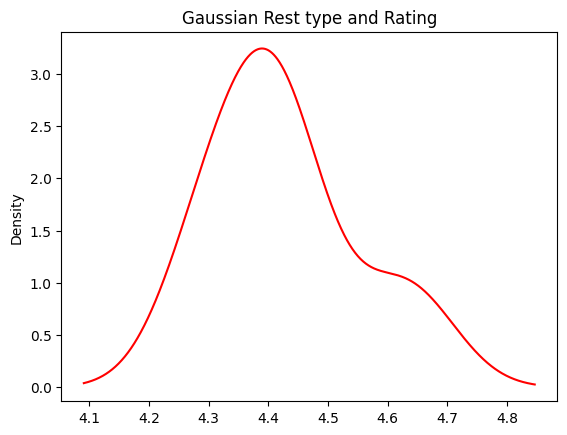

In [ ]:
# Gaussian Rest type and Rating

df.groupby(['rest_type'])['rating'].mean().nlargest(10).plot(kind='kde',title='Gaussian Rest type and Rating',color='red')

types of services

<Axes: title={'center': 'Types of Services'}, xlabel='types'>

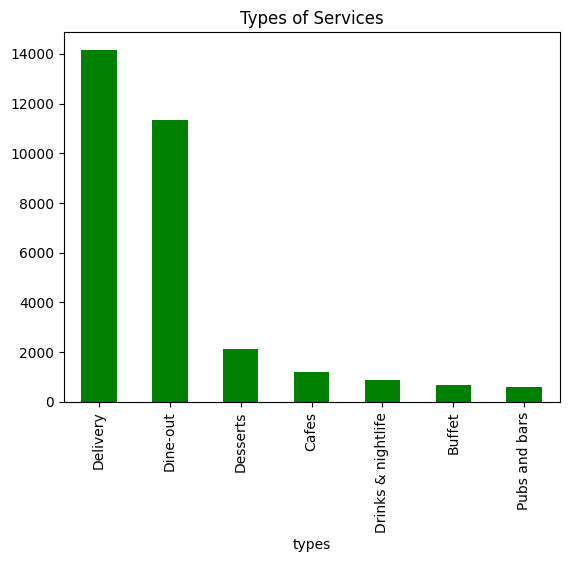

In [ ]:
# Types of Services
df['types'].value_counts().plot(kind='bar',title='Types of Services',color='green')

Relation bet type and rating

<Axes: title={'center': 'Relation between Type and Rating'}, xlabel='types'>

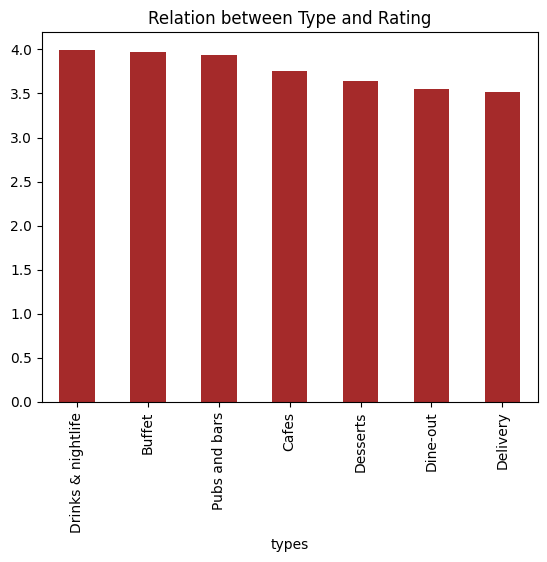

In [ ]:

df.groupby(['types'])['rating'].mean().nlargest(10).plot(kind='bar',title='Relation between Type and Rating',color='brown')

cost of restaurant

<Axes: title={'center': 'Cost of Restaurant'}, xlabel='restaurants'>

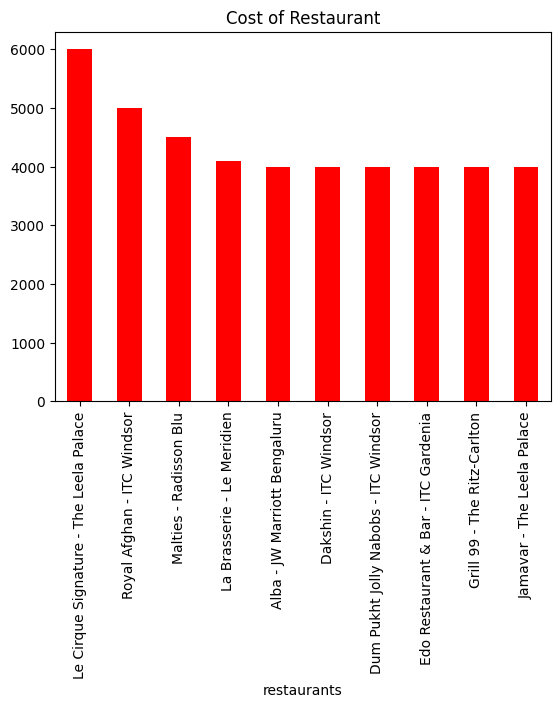

In [ ]:
df.groupby(['restaurants'])['cost'].mean().nlargest(10).plot(kind='bar',title='Cost of Restaurant',color='red')

<Axes: title={'center': 'No. of restaurants in a Location'}, xlabel='location'>

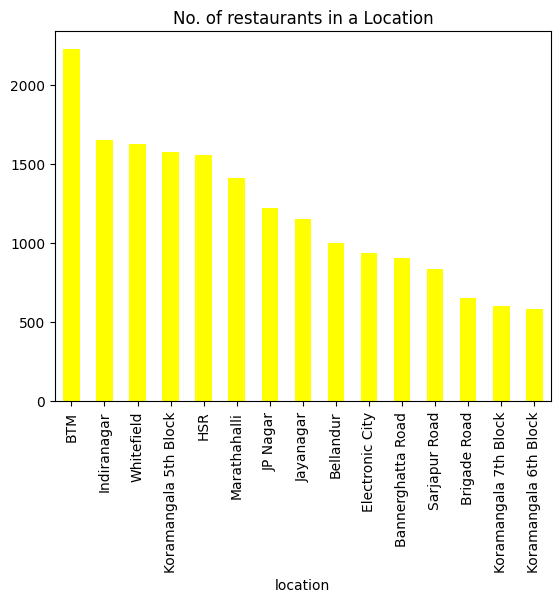

In [ ]:
df['location'].value_counts().nlargest(15).plot(kind='bar',title='No. of restaurants in a Location',color='yellow')